Implement FireGNN on composite-patient-embeddings 

In [4]:
from tqdm import trange
import sys
import os
import pandas as pd
import torch
import numpy as np
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F


# Add parent directory to path for imports
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

print(base_dir)
sys.path.append(os.path.dirname(base_dir))
from utils.graph_utils import (
    load_graph,
    build_knn_graph_from_features,
    prepare_pytorch_geometric_data,
    create_fuzzy_rules,
    get_device,
    save_graph
)

from fuzzy_models.fuzzy_models import get_fuzzy_model


/home/xyu/thesis/FireGNN/AD


In [2]:
design_path = "./data/design_with_real_target.tsv"
composite_embed_path = './data/composite_embed.pt'

design = pd.read_csv(design_path, sep='\t', index_col=0)
design['Target'] = design['Target'].map({'Control': 0, 'AD': 1, 'MCI':2})
labels = design['Target'].to_numpy()

data = torch.load(composite_embed_path)
features = torch.stack([data[idx] for idx in data.keys()]).cpu().tolist()
print('feature dimension: ', (len(features), len(features[0])))

feature dimension:  (744, 64)


In [21]:
design = pd.read_csv(design_path, sep='\t', index_col=0)
design['Old_Target'] = design['Old_Target'].map({'Control': 0, 'Disease': 1})
labels = design['Old_Target'].to_numpy()
labels

array([0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

#### Build Composite-patient graph

In [11]:
# build graph
k=5
graph = build_knn_graph_from_features(features, labels, k=k)
print(f'graph is connected: {nx.is_connected(graph)} at k={k}' )
print(f"Number of components: {nx.number_connected_components(G=graph)}")

Building k-NN graph with k=5, metric=cosine


Building initial edges: 100%|██████████| 744/744 [00:00<00:00, 266646.35it/s]


Adding label-based edges...


Adding label edges: 100%|██████████| 744/744 [00:00<00:00, 880.64it/s]


Rewiring edges for better homophily...


Rewiring edges: 100%|██████████| 744/744 [00:00<00:00, 796.62it/s]


Rewired 0 edges


Adding edges: 100%|██████████| 1404/1404 [00:00<00:00, 626201.92it/s]

graph is connected: False at k=5
Number of components: 44


In [14]:
i = 0
for n in graph.nodes(data=True):
    print(n)
    i += 1
    if i >10:
        break

(0, {'x': [0.46413809061050415, -0.030400555580854416, -1.104559302330017, 1.74724280834198, 0.29190123081207275, -0.7479617595672607, 0.2514357566833496, -0.7953881621360779, 0.7299636006355286, 0.40970131754875183, -1.4871950149536133, -1.459686517715454, 0.8940944075584412, -0.1382436454296112, 0.6041670441627502, -0.0406554751098156, 0.38142919540405273, 1.0093876123428345, 0.2800939977169037, 1.512237310409546, 1.0466663837432861, 0.8982890844345093, -0.681694746017456, -1.8615796566009521, 2.197641372680664, 0.8371537327766418, -1.3908616304397583, 0.5799614191055298, -2.656233072280884, -0.24870827794075012, 0.2559056580066681, -0.24038128554821014, -0.7819176912307739, 1.0335209369659424, 0.5807892680168152, -0.3024425208568573, 1.0379632711410522, -1.2449511289596558, -0.09911872446537018, -1.6769208908081055, -1.104928970336914, -0.13908295333385468, -1.1486254930496216, -1.4424214363098145, -0.37124699354171753, 0.17999865114688873, -1.6141358613967896, -1.592576265335083, -

#### Build Expression-patient graph
build patient graph with normalized gene expression data

In [7]:
exp_data = pd.read_csv("./data/adni_gene_cleaned.csv", index_col=0)
exp_data = exp_data.T
exp_raw_features = exp_data.to_numpy()
exp_norm = (exp_data - exp_data.min())/(exp_data.max()-exp_data.min())

# build graph input: features ()
exp_features = exp_norm.to_numpy()
exp_features.shape

(744, 19100)

In [10]:
k = 5
graph_exp = build_knn_graph_from_features(exp_features, labels,k=k)
print(f'graph is connected: {nx.is_connected(graph_exp)} at k={k}')
print(f"Number of components: {nx.number_connected_components(G=graph_exp)}")

Building k-NN graph with k=5, metric=cosine


Building initial edges: 100%|██████████| 744/744 [00:00<00:00, 399406.40it/s]


Adding label-based edges...


Adding label edges: 100%|██████████| 744/744 [00:01<00:00, 585.11it/s]


Rewiring edges for better homophily...


Rewiring edges: 100%|██████████| 744/744 [00:01<00:00, 583.77it/s]


Rewired 0 edges


Adding edges: 100%|██████████| 1463/1463 [00:00<00:00, 481691.40it/s]

graph is connected: False at k=5
Number of components: 54


#### Build graph with un-normalized expressiond data

In [11]:
k = 5
graph_rawexp = build_knn_graph_from_features(exp_raw_features, labels,k=k)
print(f'graph is connected: {nx.is_connected(graph_rawexp)} at k={k}')
print(f"Number of components: {nx.number_connected_components(G=graph_rawexp)}")

Building k-NN graph with k=5, metric=cosine


Building initial edges: 100%|██████████| 744/744 [00:00<00:00, 431851.95it/s]


Adding label-based edges...


Adding label edges: 100%|██████████| 744/744 [00:01<00:00, 555.70it/s]


Rewiring edges for better homophily...


Rewiring edges: 100%|██████████| 744/744 [00:01<00:00, 559.90it/s]


Rewired 0 edges


Adding edges: 100%|██████████| 1480/1480 [00:00<00:00, 646824.00it/s]

graph is connected: False at k=5
Number of components: 49


In [16]:
# split train, val, test data

# create masks
def create_train_val_test_masks(features, train_ratio=0.8, val_ratio=0.1):
    total_size = len(features)
    train_size, val_size, test_size = train_ratio*total_size, val_ratio* total_size, (1-train_ratio - val_ratio)*total_size

    train_mask = [i < train_size for i in range(total_size)]
    val_mask = [train_size <= i < train_size + val_size for i in range(total_size)]
    test_mask = [i >= train_size + val_size for i in range(total_size)]
    
    return train_mask, val_mask, test_mask

# add masks to nodes
def add_mask_to_graph(graph, output):
    train_mask, val_mask, test_mask = create_train_val_test_masks(features)

    for i, node in enumerate(graph.nodes()):
        graph.nodes[node]['train'] = train_mask[i]
        graph.nodes[node]['val'] = val_mask[i]
        graph.nodes[node]['test'] = test_mask[i]
    # save graph
    save_graph(graph, output)

    return graph

In [19]:
# add masks to graphs and save them 
#add_mask_to_graph(graph_exp, './data/normalized_expression_k5.pkl')
# add_mask_to_graph(graph_rawexp, './data/raw_expression_k5.pkl')
graph = add_mask_to_graph(graph, 'label3_k5.pkl')

Saved graph to label3_k5.pkl: 744 nodes, 1404 edges


In [20]:
i = 0
for n in graph.nodes(data=True):
    print(n)
    i += 1
    if i >10:
        break

(0, {'x': [0.46413809061050415, -0.030400555580854416, -1.104559302330017, 1.74724280834198, 0.29190123081207275, -0.7479617595672607, 0.2514357566833496, -0.7953881621360779, 0.7299636006355286, 0.40970131754875183, -1.4871950149536133, -1.459686517715454, 0.8940944075584412, -0.1382436454296112, 0.6041670441627502, -0.0406554751098156, 0.38142919540405273, 1.0093876123428345, 0.2800939977169037, 1.512237310409546, 1.0466663837432861, 0.8982890844345093, -0.681694746017456, -1.8615796566009521, 2.197641372680664, 0.8371537327766418, -1.3908616304397583, 0.5799614191055298, -2.656233072280884, -0.24870827794075012, 0.2559056580066681, -0.24038128554821014, -0.7819176912307739, 1.0335209369659424, 0.5807892680168152, -0.3024425208568573, 1.0379632711410522, -1.2449511289596558, -0.09911872446537018, -1.6769208908081055, -1.104928970336914, -0.13908295333385468, -1.1486254930496216, -1.4424214363098145, -0.37124699354171753, 0.17999865114688873, -1.6141358613967896, -1.592576265335083, -

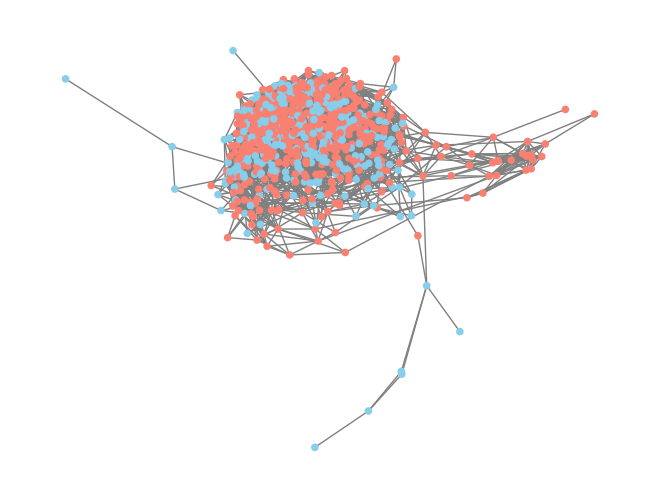

In [6]:
import matplotlib.pyplot as plt

# visulize graph
color_map = {0: 'skyblue', 1: 'salmon'}
node_colors = [color_map[x] for x in labels]
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=False, node_color= node_colors, edge_color='grey', node_size = 20)
plt.show()

In [7]:
# convert graph to pytorch_geometric_data
Data = prepare_pytorch_geometric_data(graph)
Data

Computing topological features...


Computing two-hop agreement: 100%|██████████| 744/744 [00:00<00:00, 20996.21it/s]


Data(x=[744, 64], edge_index=[2, 10910], edge_attr=[10910], y=[744], train_mask=[744], val_mask=[744], test_mask=[744], topo_features=[744, 6], topo_scaler_mean=[6], topo_scaler_scale=[6])

### Figure out FuzzyRulelayer and FuzzyModel

In [8]:
topo_features = Data.topo_features
print(topo_features)
print()
x_e = topo_features.unsqueeze(1)
x_e

tensor([[ 0.0363, -0.4130, -1.8024, -0.7133,  0.0363, -0.1924],
        [ 0.0363,  1.8808, -1.2020,  1.5538,  0.0363,  0.5698],
        [ 0.0363, -0.4949,  0.7043,  0.1736,  0.0363,  0.4785],
        ...,
        [-1.1518,  2.4952,  1.4930, -0.8355, -1.1518, -3.4470],
        [-0.8278, -0.9864, -1.1349, -0.6296, -0.8278,  0.5002],
        [ 0.0363, -1.0684,  0.2668, -0.5799,  0.0363,  0.4392]])



tensor([[[ 0.0363, -0.4130, -1.8024, -0.7133,  0.0363, -0.1924]],

        [[ 0.0363,  1.8808, -1.2020,  1.5538,  0.0363,  0.5698]],

        [[ 0.0363, -0.4949,  0.7043,  0.1736,  0.0363,  0.4785]],

        ...,

        [[-1.1518,  2.4952,  1.4930, -0.8355, -1.1518, -3.4470]],

        [[-0.8278, -0.9864, -1.1349, -0.6296, -0.8278,  0.5002]],

        [[ 0.0363, -1.0684,  0.2668, -0.5799,  0.0363,  0.4392]]])

In [9]:
centers = nn.Parameter(torch.randn(3, 6))
c = centers.unsqueeze(0)
print(c)
print()
width = nn.Parameter(torch.zeros(3,6))
rule_weights = nn.Parameter(torch.ones(3))

s = torch.exp(width).unsqueeze(0)
print(s)

tensor([[[ 0.1430, -0.0126, -1.2456, -0.9750,  1.7354, -0.5181],
         [-0.4767,  0.9009, -2.1372,  2.0486,  0.1225,  2.0062],
         [ 0.7879,  0.4461,  0.2484,  1.1963,  0.1416, -0.2653]]],
       grad_fn=<UnsqueezeBackward0>)

tensor([[[1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1.]]], grad_fn=<UnsqueezeBackward0>)


In [10]:
# Compute Gaussian membership functions
gauss = torch.exp(-((x_e - c)**2) / (2*s**2))
print(gauss)

tensor([[[9.9432e-01, 9.2297e-01, 8.5640e-01, 9.6633e-01, 2.3611e-01,
          9.4833e-01],
         [8.7672e-01, 4.2183e-01, 9.4550e-01, 2.2063e-02, 9.9629e-01,
          8.9192e-02],
         [7.5391e-01, 6.9139e-01, 1.2209e-01, 1.6151e-01, 9.9448e-01,
          9.9734e-01]],

        [[9.9432e-01, 1.6654e-01, 9.9905e-01, 4.0873e-02, 2.3611e-01,
          5.5335e-01],
         [8.7672e-01, 6.1871e-01, 6.4578e-01, 8.8478e-01, 9.9629e-01,
          3.5640e-01],
         [7.5391e-01, 3.5730e-01, 3.4927e-01, 9.3810e-01, 9.9448e-01,
          7.0560e-01]],

        [[9.9432e-01, 8.9020e-01, 1.4943e-01, 5.1702e-01, 2.3611e-01,
          6.0860e-01],
         [8.7672e-01, 3.7751e-01, 1.7651e-02, 1.7245e-01, 9.9629e-01,
          3.1129e-01],
         [7.5391e-01, 6.4225e-01, 9.0133e-01, 5.9280e-01, 9.9448e-01,
          7.5834e-01]],

        ...,

        [[4.3244e-01, 4.3084e-02, 2.3522e-02, 9.9033e-01, 1.5483e-02,
          1.3715e-02],
         [7.9619e-01, 2.8057e-01, 1.3753e-03, 1.56

In [11]:
# Product of membership functions (AND operation)
rule_activations = gauss.prod(dim=2)  # [N, num_rules]
print(rule_activations)

tensor([[1.7006e-01, 6.8555e-04, 1.0195e-02],
        [8.8346e-04, 1.1005e-01, 6.1933e-02],
        [9.8264e-03, 3.1244e-04, 1.9510e-01],
        ...,
        [9.2158e-08, 7.4306e-13, 2.9986e-06],
        [8.1105e-03, 5.4378e-04, 3.2859e-03],
        [2.5061e-02, 6.4679e-05, 3.8366e-02]], grad_fn=<ProdBackward1>)


### Training

In [12]:
@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out, fuzzy_rules = model(
        data.x,
        data.edge_index,
        edge_attr=data.edge_attr,
        topo_features=data.topo_features
    )
    preds = out.argmax(dim=1)
    correct = (preds[mask] == data.y[mask]).sum().item()
    acc = correct / mask.sum().item()
    loss = F.nll_loss(out[mask], data.y[mask]).item()
    return acc, loss, preds, fuzzy_rules


In [13]:
def train(model, data, optimizer, epochs, device):
    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in trange(epochs, desc="Training"):
        model.train()
        optimizer.zero_grad()

        out, rules = model(
            data.x,
            data.edge_index,
            edge_attr=data.edge_attr,
            topo_features=data.topo_features
        )

        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # ---- Evaluation ----
        train_acc, train_loss, _, _ = evaluate(model, data, data.train_mask)
        val_acc, val_loss, _, _ = evaluate(model, data, data.val_mask)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    return best_state, history, rules

In [14]:
device = get_device()
in_channels = Data.x.size(1)
hidden_channels = 64
out_channels = int(Data.y.max().item() + 1)

Data.to(device)

# Model
# -----------------------------------------------------
model = get_fuzzy_model(
    model_type='gcn',
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    num_rules=6
).to(device)

optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.005,
        weight_decay=5e-4
    )
print('Initial Fuzzy centers and width')
print(model.fuzzy_layer.centers)
print()
print(model.fuzzy_layer.log_sigmas)

Initial Fuzzy centers and width
Parameter containing:
tensor([[-1.0033, -0.6875, -1.2813, -0.9770, -0.5354,  0.6052],
        [ 0.6050, -0.5320, -0.8162, -0.6777, -0.4879, -1.1403],
        [-0.9711, -1.4626, -0.2780, -0.4412, -0.7919, -0.2336],
        [ 0.1220, -1.8292,  0.6167,  0.4491, -0.3198,  0.9306],
        [ 0.8404, -0.1729, -1.3692,  0.5950, -0.2121, -0.0282],
        [-0.8130, -1.6281,  1.1037,  0.9825, -0.5698, -0.4335]],
       device='cuda:0', requires_grad=True)

Parameter containing:
tensor([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]], device='cuda:0', requires_grad=True)


In [15]:
# Initialize the centers and width before training
# ----------------------------------------------------
topo_features_np = Data.topo_features.cpu().numpy()

centers, widths = create_fuzzy_rules(
    topo_features_np,
    num_rules=model.num_rules
)

with torch.no_grad():
    model.fuzzy_layer.centers.copy_(
        torch.tensor(centers, device=device, dtype=torch.float)
    )
    model.fuzzy_layer.log_sigmas.copy_(
        torch.log(torch.tensor(widths, device=device, dtype=torch.float))
    )

print('Computed Fuzzy centers and width')
print(model.fuzzy_layer.centers)
print()
print(model.fuzzy_layer.log_sigmas)

Computed Fuzzy centers and width
Parameter containing:
tensor([[-0.1633,  0.1074, -1.2780, -0.1678, -0.1633,  0.3136],
        [ 4.5882, -0.6304, -0.1443,  3.9517,  4.5882,  0.5537],
        [-0.8350,  1.3518,  1.8667, -0.8340, -0.8350, -3.1412],
        [-0.6085, -0.7910,  0.2047, -0.6908, -0.6085, -0.3428],
        [ 1.5172, -0.0803, -0.0951,  1.4464,  1.5172,  0.5390],
        [-0.0094,  0.4160,  0.5480,  0.1355, -0.0094,  0.4502]],
       device='cuda:0', requires_grad=True)

Parameter containing:
tensor([[-0.8093, -0.1651, -1.2286, -0.5747, -0.8093, -1.1475],
        [ 0.0073, -1.5030, -0.1525,  0.2939,  0.0073, -5.0294],
        [-1.0499,  0.6628, -0.2819, -5.7336, -1.0499, -0.0809],
        [-0.9080, -0.4942, -0.4436, -1.8998, -0.9080, -0.2348],
        [-0.5705, -0.7567, -0.1176, -0.2259, -0.5705, -3.8388],
        [-0.9475, -0.3853, -1.4244, -0.5325, -0.9475, -1.7934]],
       device='cuda:0', requires_grad=True)


In [16]:

device = get_device()
in_channels = Data.x.size(1)
hidden_channels = 64
out_channels = int(Data.y.max().item() + 1)

Data.to(device)

# Model
# -----------------------------------------------------
model = get_fuzzy_model(
    model_type='gcn',
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    num_rules=6
).to(device)

optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.005,
        weight_decay=5e-4
    )

# Initialize the centers and width before training
# ----------------------------------------------------
topo_features_np = Data.topo_features.cpu().numpy()

centers, widths = create_fuzzy_rules(
    topo_features_np,
    num_rules=model.num_rules
)

with torch.no_grad():
    model.fuzzy_layer.centers.copy_(
        torch.tensor(centers, device=device, dtype=torch.float)
    )
    model.fuzzy_layer.log_sigmas.copy_(
        torch.log(torch.tensor(widths, device=device, dtype=torch.float))
    )

# Train
# -----------------------------------------------------
best_state, history, rules = train(
    model=model,
    data=Data,
    optimizer=optimizer,
    epochs=100,
    device=device
)

print('\ntraining history')
for k,v in history.items():
    print(k,v)

print('\nrules')
print(rules)
# Load best model
model.load_state_dict(best_state)


# Final evaluation
# -----------------------------------------------------
test_acc, test_loss, test_preds, fuzzy_rules = evaluate(
    model, Data, Data.test_mask
)

print(f"\nTest Accuracy: {test_acc:.4f}")


Training: 100%|██████████| 100/100 [00:00<00:00, 163.45it/s]


training history
train_acc [0.6543624161073825, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6510067114093959, 0.6510067114093959, 0.6510067114093959, 0.6526845637583892, 0.6577181208053692, 0.6593959731543624, 0.6610738255033557, 0.6661073825503355, 0.6761744966442953, 0.6728187919463087, 0.6677852348993288, 0.6661073825503355, 0.6677852348993288, 0.6795302013422819, 0.6862416107382551, 0.6761744966442953, 0.6912751677852349, 0.7348993288590604, 0.7885906040268457, 0.7919463087248322, 0.790268456375839, 0.825503355704698, 0.8406040268456376, 0.8338926174496645, 0.8288590604026845, 0.8557046979865772, 0.8506711409395973, 0.8523489932885906, 0.87751677852349, 0.8624161073825504, 0.8406040268456376, 0.8708053691275168, 0.889261744966443, 0.8657718120805369, 0.85570469798657

# Paper Fuzzy Rule Implementation

In [29]:
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data


class PaperFuzzyRuleLayer(nn.Module):
    """
    FireGNN fuzzy rules exactly as defined in the paper.
    Implements Eq. (3): r_i(u) = sigmoid(alpha_i * (f_i(u) - theta_i))
    """

    def __init__(self, num_rules=6):
        super().__init__()
        self.num_rules = num_rules

        # Learnable thresholds θ_i
        self.theta = nn.Parameter(torch.zeros(num_rules))

        # Learnable sharpness α_i (initialized positive)
        self.alpha = nn.Parameter(torch.ones(num_rules))

    def forward(self, topo_features):
        """
        Args:
            topo_features: Tensor [N, 6]
                [degree, clustering coefficient, 2-hop label agreement]

        Returns:
            r: Tensor [N, 3] fuzzy rule activations
        """
        # Ensure correct dimensionality
        assert topo_features.size(1) == self.num_rules

        # r_i(u) = sigmoid(alpha_i * (f_i(u) - theta_i))
        r = torch.sigmoid(self.alpha * (topo_features - self.theta))
        return r
    
class PaperFuzzyGCN(nn.Module):
    """
    FireGNN GCN model exactly matching the paper formulation.
    """

    def __init__(self, in_channels, hidden_channels, out_channels,
                 num_layers=2, dropout=0.5, num_rules=6):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout
        d = hidden_channels

        # ---------- GCN backbone ----------
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))

        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))

        self.bns = nn.ModuleList(
            [nn.BatchNorm1d(hidden_channels) for _ in range(num_layers - 1)]
        )

        # ---------- Fuzzy rules ----------
        self.fuzzy_layer = PaperFuzzyRuleLayer(num_rules=num_rules)


        # Rule projection: Eq. (4) 
        self.rule_proj = nn.Linear(num_rules, hidden_channels)

        # Gate: Eq. (5)
        self.gate = nn.Linear(2*hidden_channels, hidden_channels)

        # Classifier
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr=None, topo_features=None):
        """
        Args:
            x: Node features [N, in_channels]
            edge_index: Graph edges
            topo_features: [N, 3] (degree, clustering, 2-hop agreement)
        """

        # ----- GCN forward -----
        for i in range(self.num_layers - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        h = self.convs[-1](x, edge_index)  # h_u

        if topo_features is not None:
            # ----- Fuzzy rule activation (Eq. 3) -----
            r = self.fuzzy_layer(topo_features)  # [N, 6]

            # ----- Rule projection (Eq. 4) ---
            e = self.rule_proj(r)
            # ----- Gating (Eq. 5) -----
            g = torch.sigmoid(self.gate(torch.cat([h, e], dim=1)))

            # ----- Fusion (Eq. 6) -----
            h_prime = g * h + (1 - g) * e

        # ----- Classification -----
        out = self.classifier(h_prime)

        return F.log_softmax(out, dim=1), r

In [30]:
paper_model = PaperFuzzyGCN(
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    num_rules=6
).to(device)

paper_model

PaperFuzzyGCN(
  (convs): ModuleList(
    (0-1): 2 x GCNConv(64, 64)
  )
  (bns): ModuleList(
    (0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fuzzy_layer): PaperFuzzyRuleLayer()
  (rule_proj): Linear(in_features=6, out_features=64, bias=True)
  (gate): Linear(in_features=128, out_features=64, bias=True)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

In [31]:
# convert graph to pytorch_geometric_data
Data = prepare_pytorch_geometric_data(graph)
Data.to(device)

Computing topological features...


Computing two-hop agreement: 100%|██████████| 744/744 [00:00<00:00, 21567.53it/s]


Data(x=[744, 64], edge_index=[2, 10910], edge_attr=[10910], y=[744], train_mask=[744], val_mask=[744], test_mask=[744], topo_features=[744, 6], topo_scaler_mean=[6], topo_scaler_scale=[6])

In [33]:
optimizer = torch.optim.Adam(
        paper_model.parameters(),
        lr=0.005,
        weight_decay=5e-4
    )

best_state, history, rules = train(
    model=paper_model,
    data=Data,
    optimizer=optimizer,
    epochs=100,
    device=device
)

print('\ntraining history')
for k,v in history.items():
    print(k,v)

print('\nrules')
print(rules)

# Load best model
paper_model.load_state_dict(best_state)


# Final evaluation
# -----------------------------------------------------
test_acc, test_loss, test_preds, fuzzy_rules = evaluate(
    paper_model, Data, Data.test_mask
)

print(f"\nTest Accuracy: {test_acc:.4f}")

Training: 100%|██████████| 100/100 [00:00<00:00, 278.09it/s]


training history
train_acc [0.9446308724832215, 0.9983221476510067, 0.9848993288590604, 0.9815436241610739, 0.9848993288590604, 0.9966442953020134, 0.9966442953020134, 0.9932885906040269, 0.9916107382550335, 0.9899328859060402, 0.9899328859060402, 0.9899328859060402, 0.9899328859060402, 0.9916107382550335, 0.9932885906040269, 0.9966442953020134, 0.9949664429530202, 0.9916107382550335, 0.9916107382550335, 0.9916107382550335, 0.9916107382550335, 0.9899328859060402, 0.9899328859060402, 0.9899328859060402, 0.9899328859060402, 0.9899328859060402, 0.9916107382550335, 0.9916107382550335, 0.9932885906040269, 0.9932885906040269, 0.9932885906040269, 0.9949664429530202, 0.9949664429530202, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9983221476510067, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.9966442953020134, 0.996644295

In [10]:
graph_file = "../datasets/three_classes/label_leakage/G_Composite_k2.pkl"
G = load_graph(graph_file)
data = prepare_pytorch_geometric_data(G)

Loaded graph from ../datasets/three_classes/label_leakage/G_Composite_k2.pkl: 744 nodes, 360 edges
Computing topological features...


Computing two-hop agreement: 100%|██████████| 744/744 [00:00<00:00, 197779.32it/s]

In [11]:
for n in G.nodes(data= True):
    print(n)
    break

(0, {'x': [0.46413809061050415, -0.030400555580854416, -1.104559302330017, 1.74724280834198, 0.29190123081207275, -0.7479617595672607, 0.2514357566833496, -0.7953881621360779, 0.7299636006355286, 0.40970131754875183, -1.4871950149536133, -1.459686517715454, 0.8940944075584412, -0.1382436454296112, 0.6041670441627502, -0.0406554751098156, 0.38142919540405273, 1.0093876123428345, 0.2800939977169037, 1.512237310409546, 1.0466663837432861, 0.8982890844345093, -0.681694746017456, -1.8615796566009521, 2.197641372680664, 0.8371537327766418, -1.3908616304397583, 0.5799614191055298, -2.656233072280884, -0.24870827794075012, 0.2559056580066681, -0.24038128554821014, -0.7819176912307739, 1.0335209369659424, 0.5807892680168152, -0.3024425208568573, 1.0379632711410522, -1.2449511289596558, -0.09911872446537018, -1.6769208908081055, -1.104928970336914, -0.13908295333385468, -1.1486254930496216, -1.4424214363098145, -0.37124699354171753, 0.17999865114688873, -1.6141358613967896, -1.592576265335083, -